# Pré-processamento
## Parte 5: Avaliação da Qualidade do Sinal (SQI)

### O que esta parte faz

Os pré-processamentos anteriores transformaram, filtraram e normalizaram os sinais.
Mas **"dado tratado" não é o mesmo que "dado confiável"**.

Esta parte responde a uma pergunta diferente:
> *Existem janelas de tempo em que o sinal simplesmente não vale nada,
> mesmo depois de filtrado: eletrodo solto, piscar de olho, choque no sensor?*

Identificamos essas janelas **antes** da extração de features para que o
modelo de reconhecimento de padrões nunca treine em dados falsos.

**O que é SQI (Signal Quality Index)?**
Não é um número único, é um conjunto de métricas calculadas em janelas
de tempo curtas que, juntas, caracterizam se aquela janela contém sinal
fisiológico real ou artefato.

Usamos quatro métricas complementares:

| Métrica | O que detecta | Threshold de rejeição |
|---------|---------------|----------------------|
| Kurtose | Spikes, piscadas, eletrodo solto por um instante | > 10 |
| Razão pico-a-pico / std | Outlier de amplitude (choque, movimento brusco) | > 10 |
| SNR proxy espectral | Eletrodo desconectado (espectro completamente plano) | < 3 dB |
| Entropia espectral | Diagnóstico qualitativo (informacional) | — |

### Por que o dado filtrado e não o normalizado?

Usamos a saída da Parte 3 (`filtered.parquet`) e não a saída da Parte 4
(`normalized.parquet`) porque:
- SQI faz mais sentido em unidades originais do sinal
- O Z-score da Parte 4 comprime a escala de amplitude, a razão pp/std
  se torna trivialmente próxima de 5 para todos os sinais clipados
- A normalização deve vir **depois** de rejeitar os artefatos, não antes

### Janelamento de 5 segundos

Usamos janelas de **5 segundos não sobrepostas** (2 500 amostras a 500 Hz).

> **Por que 5 segundos?**
> Esse valor captura pelo menos 4 ciclos completos da onda delta do EEG (1 Hz)
> e é curto o suficiente para que um artefato isolado não "contamina" uma janela
> inteira que tem 4.9 segundos de sinal bom.
> Janelas menores (1 s) seriam rejeitadas demais por artefatos pontuais;
> janelas maiores (30 s) diluiriam artefatos reais.

---
### Entrada
- `data/silver/filtered.parquet`: saída da Parte 3 (sinal filtrado, pré-normalização)

### Saídas
- `data/silver/sqi_stats.parquet`: métricas brutas de SQI por janela × canal
- `data/silver/sqi_mask.parquet`: máscara de validade por janela × canal
- `data/silver/sqi_report.txt`: relatório textual de qualidade
---

## 0. Carregar definições e dado filtrado

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy import signal as sg
from scipy import stats as sts

# ── Caminhos ──────────────────────────────────────────────────────────────────
ROOT          = Path("..")
FILTERED_PATH = ROOT / "data" / "silver" / "filtered.parquet"
SQI_STATS     = ROOT / "data" / "silver" / "sqi_stats.parquet"
SQI_MASK      = ROOT / "data" / "silver" / "sqi_mask.parquet"
SQI_REPORT    = ROOT / "data" / "silver" / "sqi_report.txt"

# ── Constantes ────────────────────────────────────────────────────────────────
FS         = 500          # frequência de amostragem (Hz)
NYQUIST    = FS / 2       # = 250 Hz

JANELA_S   = 5            # tamanho da janela em segundos
JANELA_N   = JANELA_S * FS  # = 2 500 amostras por janela
# Janelas não sobrepostas: cada janela avança JANELA_N amostras

# ── Thresholds de rejeição ────────────────────────────────────────────────────
KURT_THRESH = 10.0   # kurtose > 10  → spike, piscar, eletrodo solto
# Threshold pp/std calibrado para N=2500: teoria de valores extremos dá E[pp/std] ≈ 7.9
# para sinal gaussiano puro. Threshold=6 rejeita >65% do EEG limpo.
# Threshold=10 ≈ P98 da distribuição empírica do EEG-C3 neste dataset.
PP_THRESH   = 10.0   # pp/std  > 10  → outlier de amplitude (spikes, eletrodo solto)
SNR_THRESH  = 3.0    # SNR     < 3dB → espectro plano (eletrodo desconectado)

# ── Colunas de sinal ─────────────────────────────────────────────────────────
EEG_COLS = [
    'EEG-FP1','EEG-FP2','EEG-F3','EEG-F4','EEG-C3','EEG-C4',
    'EEG-P3','EEG-P4','EEG-O1','EEG-O2','EEG-F7','EEG-F8',
    'EEG-P7','EEG-P8','EEG-FZ','EEG-CZ','EEG-PZ',
    'EEG-FC1','EEG-FC2','EEG-CP1','EEG-CP2',
    'EEG-FC5','EEG-FC6','EEG-CP5','EEG-CP6'
]
BIO_COLS       = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS', 'IO', 'ECG']
SENSOR_NAMES   = ['LShank', 'RShank', 'Waist', 'Arm']
IMU_SINAL_SUF  = ['ACCX','ACCY','ACCZ','GYRO-X','GYRO-Y','GYRO-Z']
IMU_COLS_SINAL = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SINAL_SUF]
SIGNAL_COLS    = EEG_COLS + BIO_COLS + IMU_COLS_SINAL
META_COLS      = ['timestamp', 'patient_id', 'task_id', 'session']

# ── Carregar dado filtrado ────────────────────────────────────────────────────
print("Carregando filtered.parquet...")
df = pd.read_parquet(FILTERED_PATH)
print(f"Shape: {df.shape[0]:,} × {df.shape[1]}  "
      f"| Memória: {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"Pacientes: {sorted(df['patient_id'].unique())}")
print("Definições carregadas.")

Carregando filtered.parquet...
Shape: 1,936,470 × 63  | Memória: 548.0 MB
Pacientes: ['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012']
Definições carregadas.


## 1. Funções de SQI

Definimos quatro funções: uma para cada métrica de qualidade.
Todas recebem um vetor 1D de amostras de uma janela e retornam
um número escalar.

### Kurtose , por que detecta artefatos?

A kurtose mede o "peso das caudas" de uma distribuição.

> **Analogia:** Imagine um histograma da amplitude do sinal.
> Um sinal EEG limpo tem uma distribuição quase gaussiana ,
> a maioria dos valores fica perto de zero, com caudas moderadas.
> Quando um eletrodo solta por um instante, gera um spike enorme:
> uma barra isolada muito longe do centro no histograma.
> Isso "estica" as caudas → kurtose alta.

- Kurtose ≈ 0 (excesso): distribuição gaussiana normal → sinal ok
- Kurtose > 10: cauda muito pesada → artefato impulsivo

### Razão pico-a-pico / std

Mede quantas vezes o std (desvio padrão) cabe no maior salto de amplitude.

> **Atenção — dependência do tamanho da janela:**
> A teoria de valores extremos mostra que, para N amostras gaussianas,
> o valor esperado de pp/std cresce com N:
>
>   E[pp/std] ≈ 2 · √(2 · ln N)
>
> Para N = 2 500 amostras (janela de 5s a 500 Hz):
>
>   E[pp/std] ≈ 2 · √(2 · ln 2500) ≈ **7,9**
>
> Portanto um threshold de 6 (abaixo da média esperada para um sinal gaussiano
> completamente limpo) descartaria mais de 65 % das janelas do EEG-C3 mesmo sem
> artefato algum. Utilizamos **10** como limiar, que corresponde ao P98
> da distribuição empírica do EEG-C3 neste dataset e só é atingido por
> spikes reais (eletrodo solto por instante, piscar de olho intenso).

### SNR proxy espectral

Mede o quanto o espectro de potência é "estruturado" vs. "plano".

> **Analogia:** Um sinal EEG com ondas alpha tem picos bem definidos
> em 8–13 Hz , o espectro tem "colinas". Um eletrodo desconectado
> gera ruído branco: o espectro é completamente plano, sem colinas.
> SNR proxy = razão entre o pico máximo e o nível de piso (mediana).
> - SNR > 10 dB: espectro estruturado, sinal fisiológico provável ✅
> - SNR < 3 dB: espectro quase plano, sinal suspeito ❌

### Entropia espectral

Transforma o PSD em uma distribuição de probabilidade e calcula a
entropia de Shannon.

> - Entropia = 0: toda a energia em uma única frequência (sinal puro)
> - Entropia = 1: energia distribuída igualmente por todas as frequências (ruído branco puro)
>
> Para EEG: esperamos entropia entre 0.7 e 0.95 (sinal complexo mas estruturado).
> Para IMU: esperamos entropia mais baixa (movimento concentrado em poucos Hz).
> Para EMG pós-correção (sem high-pass): espera-se entropia moderada.
>
> **Não usamos como critério de rejeição** pois o threshold ideal varia
> por tipo de canal , mas guardamos para análise e para o relatório.

In [15]:
def calcular_kurtose(sinal: np.ndarray) -> float:
    """
    Kurtose de Fisher (excesso de curtose).
    Normal → 0.0 | Spike isolado → >> 10

    Usamos `bias=False` (correção amostral) pois janelas de 5s
    têm 2500 pontos , grande o suficiente para a correção ser pequena,
    mas boa prática manter.
    """
    if np.std(sinal) < 1e-10:
        # Canal constante (sensor offline preenchido com zero)
        return 0.0
    return float(sts.kurtosis(sinal, fisher=True, bias=False))


def calcular_pp_ratio(sinal: np.ndarray) -> float:
    """
    Razão pico-a-pico / desvio padrão.

    Para N amostras gaussianas: E[pp/std] ≈ 2·sqrt(2·ln N).
    Com N=2500, esse valor é ≈ 7.9, portanto o threshold
    deve ser calibrado por janela (PP_THRESH = 10.0 aqui).
    Valores > PP_THRESH indicam spike de amplitude real.
    """
    std = np.std(sinal)
    if std < 1e-10:
        return 0.0
    pp = sinal.max() - sinal.min()
    return float(pp / std)


def calcular_snr_proxy(sinal: np.ndarray, fs: int = FS,
                        nperseg: int = JANELA_N) -> float:
    """
    SNR proxy: razão entre o pico máximo do espectro e o nível de piso.

    Computamos o PSD via Welch com nperseg = janela inteira (uma única
    estimativa espectral da janela). A razão max/mediana em escala dB
    diz o quanto o espectro é 'estruturado' vs. 'plano como ruído'.

    Retorna valor em dB.
    - > 10 dB : espectro com pico claro (sinal estruturado) ✅
    -  3–10 dB: estrutura moderada (aceitável)
    - < 3  dB : espectro quase plano → suspeito de eletrodo desconectado ❌
    """
    if np.std(sinal) < 1e-10:
        return 0.0
    freqs, psd = sg.welch(sinal, fs=fs, nperseg=min(nperseg, len(sinal)),
                           scaling='density')
    psd_max    = psd.max()
    psd_mediana = np.median(psd)
    if psd_mediana < 1e-30:
        return 60.0   # sinal perfeito (nunca acontece na prática)
    return float(10 * np.log10(psd_max / psd_mediana + 1e-10))


def calcular_entropia_espectral(sinal: np.ndarray, fs: int = FS,
                                  nperseg: int = JANELA_N) -> float:
    """
    Entropia de Shannon do espectro de potência normalizado.

    Normaliza o PSD para somar 1 (torna-se uma distribuição de probabilidade)
    e computa a entropia. Normaliza pelo log2(N) para ficar em [0, 1].

    - Próximo de 0 : energia concentrada em poucas frequências (sinal puro)
    - Próximo de 1 : energia distribuída uniformemente (ruído branco)
    """
    if np.std(sinal) < 1e-10:
        return 1.0   # sinal constante = máxima desordem espectral do ponto de vista de entropia

    _, psd = sg.welch(sinal, fs=fs, nperseg=min(nperseg, len(sinal)),
                       scaling='density')
    psd_norm  = psd / (psd.sum() + 1e-30)
    # Clip para evitar log(0)
    psd_norm  = np.clip(psd_norm, 1e-30, None)
    entropia  = -np.sum(psd_norm * np.log2(psd_norm))
    n_bins    = len(psd_norm)
    return float(entropia / np.log2(n_bins))   # normaliza para [0, 1]


def avaliar_janela(sinal: np.ndarray) -> dict:
    """
    Calcula todas as métricas SQI de uma janela de um único canal.
    Retorna dict com as métricas e a flag 'valida'.

    A janela é marcada como INVÁLIDA se qualquer critério de rejeição dispara:
      - kurtose   > KURT_THRESH (10.0)
      - pp_ratio  > PP_THRESH   (10.0)
      - snr_db    < SNR_THRESH  (3.0 dB)
    """
    kurtose  = calcular_kurtose(sinal)
    pp_ratio = calcular_pp_ratio(sinal)
    snr_db   = calcular_snr_proxy(sinal)
    entropia = calcular_entropia_espectral(sinal)

    # Critérios de rejeição
    rejeitado_kurt   = kurtose  > KURT_THRESH
    rejeitado_pp     = pp_ratio > PP_THRESH
    rejeitado_snr    = snr_db   < SNR_THRESH

    valida = not (rejeitado_kurt or rejeitado_pp or rejeitado_snr)

    return {
        'kurtose'          : kurtose,
        'pp_ratio'         : pp_ratio,
        'snr_db'           : snr_db,
        'entropia_espectral': entropia,
        'rej_kurtose'      : rejeitado_kurt,
        'rej_pp'           : rejeitado_pp,
        'rej_snr'          : rejeitado_snr,
        'valida'           : valida,
    }


print("Funções SQI definidas:")
print(f"  calcular_kurtose()        → threshold rejeição: > {KURT_THRESH}")
print(f"  calcular_pp_ratio()       → threshold rejeição: > {PP_THRESH}")
print(f"  calcular_snr_proxy()      → threshold rejeição: < {SNR_THRESH} dB")
print(f"  calcular_entropia_espectral() → apenas informacional")
print(f"  avaliar_janela()          → combina tudo, retorna 'valida'")

Funções SQI definidas:
  calcular_kurtose()        → threshold rejeição: > 10.0
  calcular_pp_ratio()       → threshold rejeição: > 10.0
  calcular_snr_proxy()      → threshold rejeição: < 3.0 dB
  calcular_entropia_espectral() → apenas informacional
  avaliar_janela()          → combina tudo, retorna 'valida'


## 2. Identificar tipo de canal por coluna

Precisamos saber o tipo de cada canal para exibir os resultados
agrupados por tipo (EEG / EMG / IMU / Bio) no relatório final.
Não muda nada na computação , todas as métricas são calculadas
da mesma forma independente do tipo.

In [16]:
def tipo_canal(col: str) -> str:
    """
    Retorna o tipo fisiológico de um canal pelo nome.
    Usado apenas para agrupamento nos relatórios e gráficos.
    """
    if col.startswith('EEG'):
        return 'EEG'
    if col.startswith('EMG'):
        return 'EMG'
    if col in ('ECG', 'IO'):
        return 'BIO'
    return 'IMU'


# Canais presentes no arquivo (pode variar entre pacientes)
SIGNAL_COLS_PRESENTES = [c for c in SIGNAL_COLS if c in df.columns]
print(f"Canais de sinal disponíveis: {len(SIGNAL_COLS_PRESENTES)}")
for tp in ['EEG', 'EMG', 'BIO', 'IMU']:
    cols_tp = [c for c in SIGNAL_COLS_PRESENTES if tipo_canal(c) == tp]
    print(f"  {tp}: {len(cols_tp)} canais , {cols_tp[:4]}{'...' if len(cols_tp)>4 else ''}")

Canais de sinal disponíveis: 54
  EEG: 25 canais , ['EEG-FP1', 'EEG-FP2', 'EEG-F3', 'EEG-F4']...
  EMG: 3 canais , ['EMG-RTA', 'EMG-LTA', 'EMG-RGS']
  BIO: 2 canais , ['IO', 'ECG']
  IMU: 24 canais , ['LShank-ACCX', 'LShank-ACCY', 'LShank-ACCZ', 'LShank-GYRO-X']...


## 3. Calcular SQI por janela × paciente × canal

Loop principal: para cada paciente, divide o sinal em janelas de 5s
e calcula as quatro métricas em cada canal de cada janela.

**Resultado:** um DataFrame em formato longo onde cada linha representa
um triplet (paciente, início da janela, canal) com suas métricas.

> **Formato longo vs. largo:**
> Poderíamos ter uma coluna por canal (formato largo , 50 colunas de kurtose).
> Usamos o formato longo porque é mais flexível para filtrar por tipo de canal,
> agrupar por paciente e exportar para análise posterior.
>
> Para cruzar com o `normalized.parquet` no PP6, usaremos
> `(patient_id, n_inicio)` como chave , o `n_inicio` é a posição
> da amostra dentro do bloco de amostras daquele paciente (0-based).

Este loop é o passo mais demorado do notebook , calcular Welch em
2 500 pontos × 50 canais × ~200 janelas × 12 pacientes leva alguns minutos.

In [17]:
print("Calculando SQI por janela × paciente × canal...")
print("=" * 60)

registros = []

for pid in sorted(df['patient_id'].unique()):
    df_pid = df[df['patient_id'] == pid].reset_index(drop=True)
    n_total = len(df_pid)
    n_janelas = n_total // JANELA_N

    if n_janelas == 0:
        print(f"  {pid}: dados insuficientes para 1 janela de {JANELA_S}s , pulando")
        continue

    print(f"  {pid}: {n_total:,} amostras → {n_janelas} janelas de {JANELA_S}s")

    for j in range(n_janelas):
        n_ini = j * JANELA_N
        n_fim = n_ini + JANELA_N
        df_jan = df_pid.iloc[n_ini:n_fim]

        # task_id da janela = task do primeiro sample (janelas de transição
        # entre tasks serão identificadas depois com flag especial)
        task_ini = df_jan['task_id'].iloc[0]  if 'task_id'  in df_jan.columns else None
        task_fim = df_jan['task_id'].iloc[-1] if 'task_id'  in df_jan.columns else None
        # Se a janela cruzou uma fronteira de task, marcamos (transição)
        transicao = (task_ini != task_fim)

        for col in SIGNAL_COLS_PRESENTES:
            sinal = df_jan[col].values.astype(float)

            # Canal todo NaN → sensor ausente nesta janela; não avaliar
            if np.all(np.isnan(sinal)):
                registros.append({
                    'patient_id'         : pid,
                    'janela_idx'         : j,
                    'n_inicio'           : n_ini,
                    'n_fim'              : n_fim,
                    'task_id'            : task_ini,
                    'janela_transicao'   : transicao,
                    'canal'              : col,
                    'tipo'               : tipo_canal(col),
                    'kurtose'            : np.nan,
                    'pp_ratio'           : np.nan,
                    'snr_db'             : np.nan,
                    'entropia_espectral' : np.nan,
                    'rej_kurtose'        : False,
                    'rej_pp'             : False,
                    'rej_snr'            : False,
                    'valida'             : False,  # ausente = inválida
                    'sensor_ausente'     : True,
                })
                continue

            # Substituir NaNs internos (pontuais) por interpolação linear
            if np.any(np.isnan(sinal)):
                sinal = pd.Series(sinal).interpolate(
                    method='linear', limit_direction='both').values

            metricas = avaliar_janela(sinal)

            registros.append({
                'patient_id'         : pid,
                'janela_idx'         : j,
                'n_inicio'           : n_ini,
                'n_fim'              : n_fim,
                'task_id'            : task_ini,
                'janela_transicao'   : transicao,
                'canal'              : col,
                'tipo'               : tipo_canal(col),
                **metricas,
                'sensor_ausente'     : False,
            })

    print(f"         ✅ concluído")

df_sqi = pd.DataFrame(registros)
print()
print(f"SQI calculado: {len(df_sqi):,} registros "
      f"({df_sqi['patient_id'].nunique()} pacientes × "
      f"{df_sqi['canal'].nunique()} canais)")
print(f"Formato: {df_sqi.shape[0]:,} linhas × {df_sqi.shape[1]} colunas")

Calculando SQI por janela × paciente × canal...
  001: 110,582 amostras → 44 janelas de 5s
         ✅ concluído
  002: 235,098 amostras → 94 janelas de 5s
         ✅ concluído
  003: 261,385 amostras → 104 janelas de 5s
         ✅ concluído
  004: 112,327 amostras → 44 janelas de 5s
         ✅ concluído
  005: 92,351 amostras → 36 janelas de 5s
         ✅ concluído
  006: 108,065 amostras → 43 janelas de 5s
         ✅ concluído
  007: 163,304 amostras → 65 janelas de 5s
         ✅ concluído
  008: 184,020 amostras → 73 janelas de 5s
         ✅ concluído
  009: 135,806 amostras → 54 janelas de 5s
         ✅ concluído
  010: 215,520 amostras → 86 janelas de 5s
         ✅ concluído
  011: 166,308 amostras → 66 janelas de 5s
         ✅ concluído
  012: 151,704 amostras → 60 janelas de 5s
         ✅ concluído

SQI calculado: 41,526 registros (12 pacientes × 54 canais)
Formato: 41,526 linhas × 17 colunas


## 4. Salvar as métricas SQI brutas

Salvamos o DataFrame completo de métricas antes de gerar a máscara,
para que análises posteriores possam re-examinar cada janela individualmente
sem precisar recalcular tudo.

In [18]:
df_sqi.to_parquet(SQI_STATS, index=False)
print(f"Métricas SQI salvas em: {SQI_STATS}")
print(f"Shape: {df_sqi.shape}")
print()
print("Primeiras linhas:")
print(df_sqi[['patient_id','janela_idx','n_inicio','canal','tipo',
               'kurtose','pp_ratio','snr_db','entropia_espectral','valida']].head(10).to_string(index=False))

Métricas SQI salvas em: ../data/silver/sqi_stats.parquet
Shape: (41526, 17)

Primeiras linhas:
patient_id  janela_idx  n_inicio   canal tipo   kurtose  pp_ratio     snr_db  entropia_espectral  valida
       001           0         0 EEG-FP1  EEG 14.874964  8.498728 145.774283            0.487613   False
       001           0         0 EEG-FP2  EEG 18.860160  8.191211 155.740495            0.461975   False
       001           0         0  EEG-F3  EEG  0.102522  5.772329 145.677240            0.558805    True
       001           0         0  EEG-F4  EEG  5.804586  7.577271 143.635689            0.559773    True
       001           0         0  EEG-C3  EEG  5.221344  8.037887 145.796571            0.598870    True
       001           0         0  EEG-C4  EEG  0.160557  6.602827 142.331442            0.608019    True
       001           0         0  EEG-P3  EEG  4.297396  7.914041 141.402923            0.612339    True
       001           0         0  EEG-P4  EEG  1.690841  7.127189

## 5. Visualização: Distribuição das Métricas SQI

### 5.1 Histogramas de kurtose por tipo de canal

Esperamos que a maior parte das janelas tenha kurtose baixa (< 3) , sinal limpo.
Janelas com kurtose > 10 (linha vermelha) são as candidatas a rejeição.

Se o histograma mostrar uma longa cauda à direita além de 10,
isso indica presença real de artefatos no dataset.
Se quase tudo estiver abaixo de 10, o sinal está muito limpo.

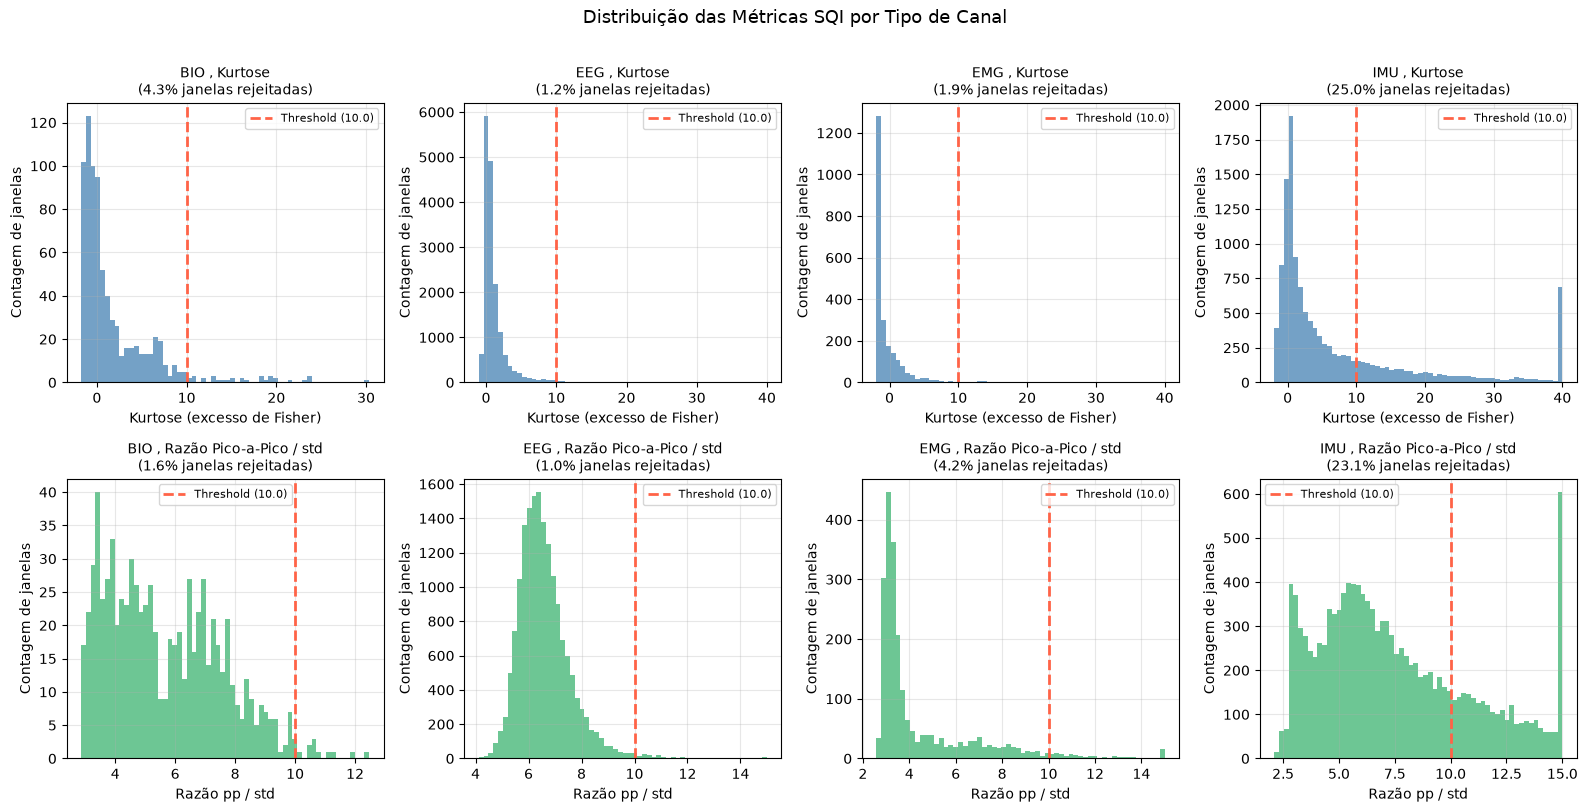


Interpretação:
  Barras à DIREITA do threshold vermelho = janelas rejeitadas.
  O ideal é que a grande maioria das barras fique à esquerda.


In [19]:
df_validas = df_sqi[~df_sqi['sensor_ausente']]

tipos = df_validas['tipo'].unique()
n_tipos = len(tipos)

fig, axes = plt.subplots(2, n_tipos, figsize=(4 * n_tipos, 8))
if n_tipos == 1:
    axes = np.array(axes).reshape(2, 1)

for col_ax, tp in enumerate(sorted(tipos)):
    subset = df_validas[df_validas['tipo'] == tp]

    # --- Kurtose ---
    ax = axes[0, col_ax]
    vals_kurt = subset['kurtose'].dropna()
    # Clip para visualização (outliers extremos distorcem o eixo)
    vals_kurt_vis = vals_kurt.clip(upper=40)
    ax.hist(vals_kurt_vis, bins=60, color='steelblue', alpha=0.75, edgecolor='none')
    ax.axvline(KURT_THRESH, color='tomato', lw=2, ls='--',
               label=f'Threshold ({KURT_THRESH})')
    pct_rejeitadas = (vals_kurt > KURT_THRESH).mean() * 100
    ax.set_title(f'{tp} , Kurtose\n({pct_rejeitadas:.1f}% janelas rejeitadas)',
                 fontsize=10)
    ax.set_xlabel('Kurtose (excesso de Fisher)')
    ax.set_ylabel('Contagem de janelas')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Razão pp/std ---
    ax2 = axes[1, col_ax]
    vals_pp = subset['pp_ratio'].dropna()
    vals_pp_vis = vals_pp.clip(upper=15)
    ax2.hist(vals_pp_vis, bins=60, color='mediumseagreen', alpha=0.75, edgecolor='none')
    ax2.axvline(PP_THRESH, color='tomato', lw=2, ls='--',
                label=f'Threshold ({PP_THRESH})')
    pct_pp = (vals_pp > PP_THRESH).mean() * 100
    ax2.set_title(f'{tp} , Razão Pico-a-Pico / std\n({pct_pp:.1f}% janelas rejeitadas)',
                  fontsize=10)
    ax2.set_xlabel('Razão pp / std')
    ax2.set_ylabel('Contagem de janelas')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)

plt.suptitle('Distribuição das Métricas SQI por Tipo de Canal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print()
print("Interpretação:")
print("  Barras à DIREITA do threshold vermelho = janelas rejeitadas.")
print("  O ideal é que a grande maioria das barras fique à esquerda.")

### 5.2 Histogramas de SNR proxy e Entropia Espectral

O SNR proxy mede se o espectro tem "colinas" (sinal estruturado)
ou é completamente plano (ruído/eletrodo desconectado).

A entropia espectral complementa esse diagnóstico: alta entropia
(próxima de 1) → espectro plano → sinal suspeito.

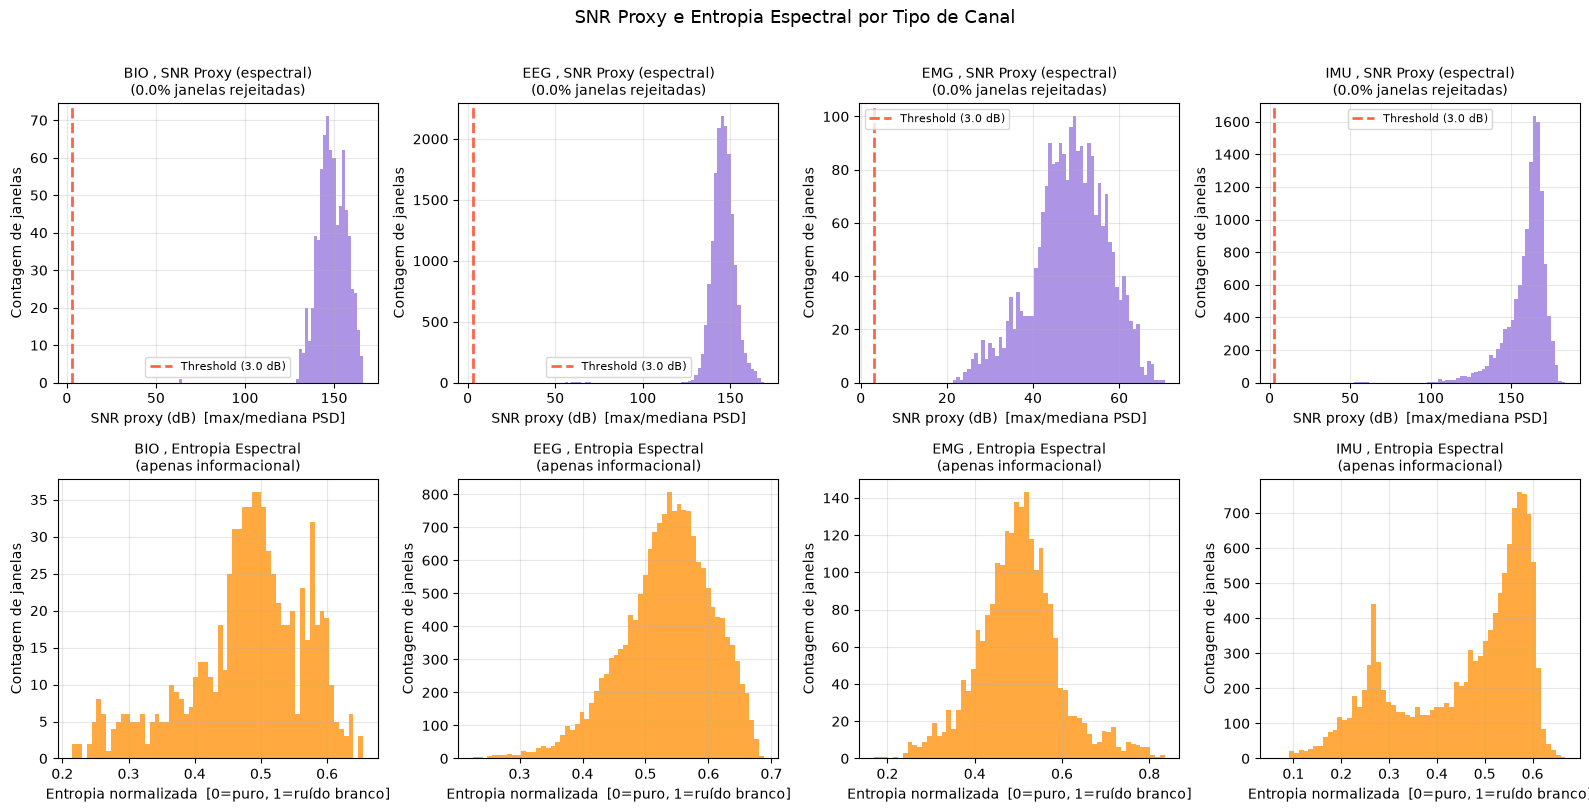

In [20]:
fig, axes = plt.subplots(2, n_tipos, figsize=(4 * n_tipos, 8))
if n_tipos == 1:
    axes = np.array(axes).reshape(2, 1)

for col_ax, tp in enumerate(sorted(tipos)):
    subset = df_validas[df_validas['tipo'] == tp]

    # --- SNR proxy ---
    ax = axes[0, col_ax]
    vals_snr = subset['snr_db'].dropna()
    ax.hist(vals_snr, bins=60, color='mediumpurple', alpha=0.75, edgecolor='none')
    ax.axvline(SNR_THRESH, color='tomato', lw=2, ls='--',
               label=f'Threshold ({SNR_THRESH} dB)')
    pct_snr = (vals_snr < SNR_THRESH).mean() * 100
    ax.set_title(f'{tp} , SNR Proxy (espectral)\n({pct_snr:.1f}% janelas rejeitadas)',
                 fontsize=10)
    ax.set_xlabel('SNR proxy (dB)  [max/mediana PSD]')
    ax.set_ylabel('Contagem de janelas')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # --- Entropia espectral ---
    ax2 = axes[1, col_ax]
    vals_ent = subset['entropia_espectral'].dropna()
    ax2.hist(vals_ent, bins=60, color='darkorange', alpha=0.75, edgecolor='none')
    ax2.set_title(f'{tp} , Entropia Espectral\n(apenas informacional)',
                  fontsize=10)
    ax2.set_xlabel('Entropia normalizada  [0=puro, 1=ruído branco]')
    ax2.set_ylabel('Contagem de janelas')
    ax2.grid(True, alpha=0.3)

plt.suptitle('SNR Proxy e Entropia Espectral por Tipo de Canal', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 5.3 Exemplos visuais: janela BOA vs. janela RUIM

O melhor teste de qualquer métricas é o "cheiro": olhar visualmente
uma janela marcada como ruim e confirmar que realmente parece um artefato.

Fazemos isso para EEG-C3, EMG-RTA e um canal IMU representativo.
Para cada canal, buscamos:
- A janela com **menor kurtose** (a "mais limpa")
- A janela com **maior kurtose** (o pior artefato)

E plotamos a série temporal + espectro de potência lado a lado.

/tmp/ipykernel_278767/224223858.py:66: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_278767/224223858.py:66: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/natan/Área de trabalho/rec_pad/TI093-biosignals-acquisition/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/natan/Área de trabalho/rec_pad/TI093-biosignals-acquisition/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


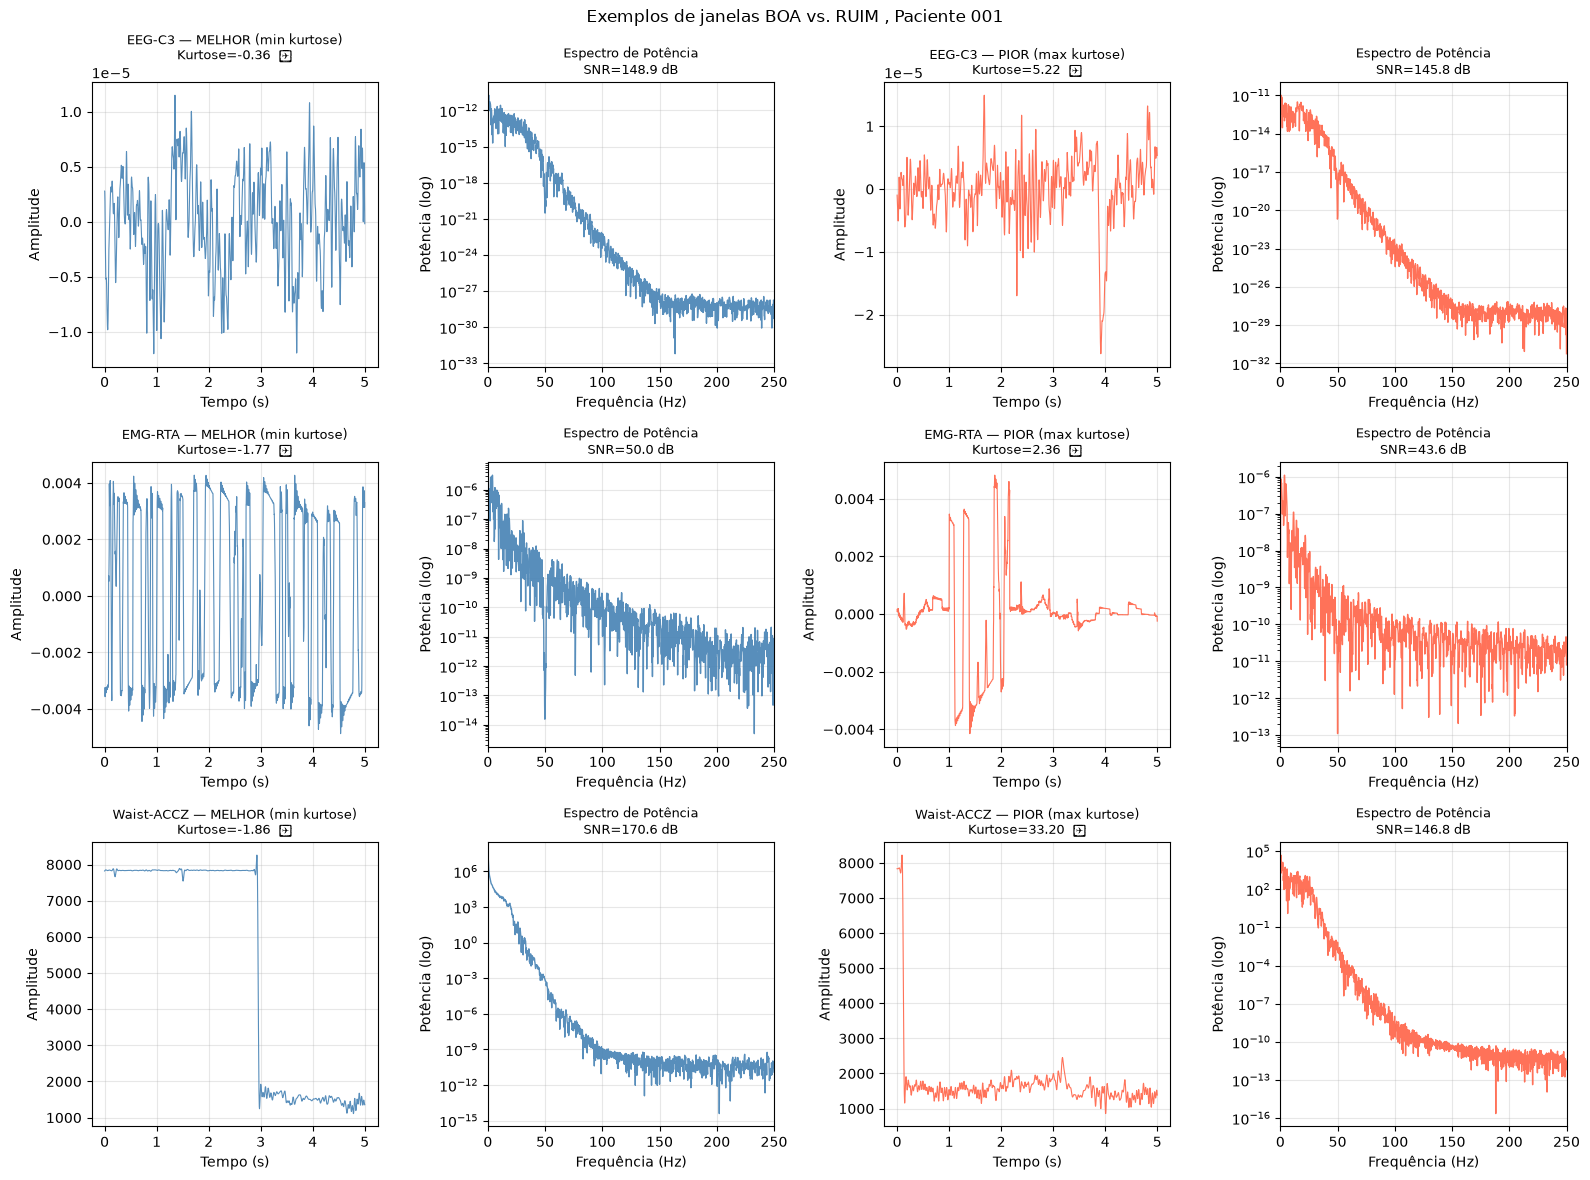


Interpretação:
  A janela BOA deve mostrar sinal suave e espectro com estrutura.
  A janela RUIM deve mostrar spike(s) e espectro distorcido/plano.


In [21]:
canais_exemplo = ['EEG-C3', 'EMG-RTA', 'Waist-ACCZ']
canais_exemplo = [c for c in canais_exemplo if c in SIGNAL_COLS_PRESENTES]

# Usar o primeiro paciente com dados completos
pid_demo = df_sqi['patient_id'].iloc[0]
df_pid_demo = df[df['patient_id'] == pid_demo].reset_index(drop=True)

fig, axes = plt.subplots(len(canais_exemplo), 4,
                          figsize=(16, 4 * len(canais_exemplo)))
if len(canais_exemplo) == 1:
    axes = axes[np.newaxis, :]

for row_ax, col in enumerate(canais_exemplo):
    subset_col = df_sqi[
        (df_sqi['patient_id'] == pid_demo) &
        (df_sqi['canal'] == col) &
        (~df_sqi['sensor_ausente'])
    ].dropna(subset=['kurtose'])

    if subset_col.empty:
        for ax in axes[row_ax]:
            ax.text(0.5, 0.5, f'{col}\nauseente neste paciente',
                    ha='center', va='center', transform=ax.transAxes)
        continue

    # Janela melhor (min kurtose) e pior (max kurtose)
    idx_melhor = subset_col['kurtose'].idxmin()
    idx_pior   = subset_col['kurtose'].idxmax()
    t = np.linspace(0, JANELA_S, JANELA_N)

    for col_ax, (idx, titulo, cor) in enumerate([
        (idx_melhor, 'MELHOR (min kurtose)', 'steelblue'),
        (idx_pior,   'PIOR (max kurtose)',   'tomato'),
    ]):
        row = subset_col.loc[idx]
        n_ini = int(row['n_inicio'])
        sinal = df_pid_demo[col].values[n_ini:n_ini + JANELA_N].astype(float)
        kurt  = row['kurtose']
        valid = '✅' if row['valida'] else '❌'

        # Série temporal
        ax_ts = axes[row_ax, col_ax * 2]
        ax_ts.plot(t, sinal, lw=0.8, color=cor, alpha=0.9)
        ax_ts.set_title(f'{col} — {titulo}\nKurtose={kurt:.2f}  {valid}',
                         fontsize=9)
        ax_ts.set_xlabel('Tempo (s)')
        ax_ts.set_ylabel('Amplitude')
        ax_ts.grid(True, alpha=0.3)

        # Espectro
        ax_sp = axes[row_ax, col_ax * 2 + 1]
        sinal_clean = pd.Series(sinal).interpolate(
            method='linear', limit_direction='both').values
        freqs, psd = sg.welch(sinal_clean, fs=FS, nperseg=JANELA_N,
                               scaling='density')
        ax_sp.semilogy(freqs, psd, lw=1.0, color=cor, alpha=0.9)
        ax_sp.set_title(f'Espectro de Potência\nSNR={row["snr_db"]:.1f} dB',
                         fontsize=9)
        ax_sp.set_xlabel('Frequência (Hz)')
        ax_sp.set_ylabel('Potência (log)')
        ax_sp.grid(True, alpha=0.3)
        ax_sp.set_xlim(0, NYQUIST)

plt.suptitle(f'Exemplos de janelas BOA vs. RUIM , Paciente {pid_demo}',
              fontsize=12)
plt.tight_layout()
plt.show()

print()
print("Interpretação:")
print("  A janela BOA deve mostrar sinal suave e espectro com estrutura.")
print("  A janela RUIM deve mostrar spike(s) e espectro distorcido/plano.")

## 6. Gerar a Máscara de Janelas Válidas

A máscara é o produto principal deste notebook.
É um DataFrame com uma linha por (paciente × janela × canal)
e uma coluna `valida` que o PP6 (segmentação) usará para excluir
janelas problemáticas.

### Critério composto por canal

Uma janela é considerada **válida para um canal** se:
1. O sensor não estava ausente (`sensor_ausente == False`)
2. Kurtose ≤ 10 (`rej_kurtose == False`)
3. Razão pp/std ≤ 10 (`rej_pp == False`)
4. SNR proxy ≥ 3 dB (`rej_snr == False`)

### Critério global da janela

Uma janela é **globalmente válida** se todos os canais-chave
(EEG e EMG no mínimo) são válidos nessa janela.
IMU e Bio entram como critério secundário , documentados mas
não impedem o uso da janela se os canais neurais estiverem limpos.

> Essa hierarquia reflete a prioridade analítica:
> o que mais importa para reconhecimento de padrões motores (FOG)
> é a integridade dos sinais neurais e musculares.

In [22]:
# ── Colunas-chave: canais que DEVEM ser válidos para validar a janela globalmente
CANAIS_CHAVE = [c for c in ['EEG-C3', 'EEG-FP1', 'EMG-RTA']
                if c in SIGNAL_COLS_PRESENTES]

print(f"Canais-chave para validação global: {CANAIS_CHAVE}")
print()

# ── Pivot: para cada (patient_id, janela_idx), um valor de 'valida' por canal ──
# Isso cria o 'validity pivot' que o PP6 usará como lookup
df_mask_wide = df_sqi.pivot_table(
    index=['patient_id', 'janela_idx', 'n_inicio', 'n_fim',
           'task_id', 'janela_transicao'],
    columns='canal',
    values='valida',
    aggfunc='first'   # uma linha por (paciente, janela, canal)
).reset_index()

# Nomes de coluna limpos: 'EEG-C3__valida' etc.
df_mask_wide.columns.name = None
canal_cols = [c for c in df_mask_wide.columns
              if c not in ['patient_id','janela_idx','n_inicio','n_fim',
                           'task_id','janela_transicao']]
df_mask_wide.rename(columns={c: f'{c}__valida' for c in canal_cols},
                    inplace=True)

# ── Critério global: todos os canais-chave válidos ──
cols_chave_valida = [f'{c}__valida' for c in CANAIS_CHAVE
                     if f'{c}__valida' in df_mask_wide.columns]

if cols_chave_valida:
    df_mask_wide['janela_global_valida'] = df_mask_wide[cols_chave_valida].all(axis=1)
else:
    # Fallback: todos os canais EEG disponíveis
    cols_eeg_valida = [c for c in df_mask_wide.columns
                       if c.startswith('EEG') and c.endswith('__valida')]
    df_mask_wide['janela_global_valida'] = df_mask_wide[cols_eeg_valida].all(axis=1)

# ── Também adicionar flag de janela de transição (task boundary) ──
# Janelas de transição devem ser descartadas na segmentação (PP6)
df_mask_wide['janela_transicao'] = df_mask_wide['janela_transicao'].fillna(False)

# Janela aprovada para extração = válida globalmente E não é transição
df_mask_wide['aprovada_para_extracao'] = (
    df_mask_wide['janela_global_valida'] &
    ~df_mask_wide['janela_transicao']
)

# ── Salvar ──
df_mask_wide.to_parquet(SQI_MASK, index=False)
print(f"Máscara salva em: {SQI_MASK}")
print(f"Shape: {df_mask_wide.shape}")
print()

# ── Resumo geral ──
total   = len(df_mask_wide)
validas = df_mask_wide['aprovada_para_extracao'].sum()
pct     = validas / total * 100
print(f"Resumo geral:")
print(f"  Total de janelas: {total:,}")
print(f"  Aprovadas para extração: {validas:,}  ({pct:.1f}%)")
print(f"  Rejeitadas: {total - validas:,}  ({100-pct:.1f}%)")

Canais-chave para validação global: ['EEG-C3', 'EEG-FP1', 'EMG-RTA']

Máscara salva em: ../data/silver/sqi_mask.parquet
Shape: (769, 62)

Resumo geral:
  Total de janelas: 769
  Aprovadas para extração: 651  (84.7%)
  Rejeitadas: 118  (15.3%)


### 6.1 Decomposição das rejeições por critério

Queremos saber qual critério está descartando mais janelas.
Se > 90% das rejeições for por kurtose, o sinal tem muitos spikes.
Se for por SNR, muitos eletrodos estão desconectando.

In [23]:
df_rej = df_sqi[~df_sqi['sensor_ausente']].copy()

print("Contribuição de cada critério para rejeições (todas as janelas × canais):")
print("-" * 60)
total_janelas_canal = len(df_rej)
for criterio, col_rej in [
    ('Kurtose > 10',      'rej_kurtose'),
    ('pp/std > 10',       'rej_pp'),
    ('SNR < 3 dB',        'rej_snr'),
]:
    n = df_rej[col_rej].sum()
    pct = n / total_janelas_canal * 100
    barra = '█' * int(pct / 2)
    print(f"  {criterio:<18}: {n:>8,}  ({pct:5.1f}%)  {barra}")

print()
print("Por tipo de canal:")
print("-" * 60)
for tp in sorted(df_rej['tipo'].unique()):
    sub = df_rej[df_rej['tipo'] == tp]
    n_tot = len(sub)
    n_inv = (~sub['valida']).sum()
    pct   = n_inv / n_tot * 100 if n_tot else 0
    print(f"  {tp:<6}: {n_inv:>6,} / {n_tot:>7,} janelas-canal rejeitadas  ({pct:.1f}%)")

Contribuição de cada critério para rejeições (todas as janelas × canais):
------------------------------------------------------------
  Kurtose > 10      :    3,420  ( 10.5%)  █████
  pp/std > 10       :    3,175  (  9.8%)  ████
  SNR < 3 dB        :        0  (  0.0%)  

Por tipo de canal:
------------------------------------------------------------
  BIO   :     36 /     769 janelas-canal rejeitadas  (4.7%)
  EEG   :    306 /  16,918 janelas-canal rejeitadas  (1.8%)
  EMG   :    118 /   2,307 janelas-canal rejeitadas  (5.1%)
  IMU   :  3,481 /  12,552 janelas-canal rejeitadas  (27.7%)


### 6.2 Taxa de aprovação por paciente

Tabela completa mostrando, para cada paciente, quantas janelas
estão aprovadas para a extração de features.

In [24]:
print("Taxa de aprovação por paciente:")
print("-" * 55)
print(f"  {'Paciente':<12} {'Total':>8} {'Aprovadas':>10} {'Rejeitadas':>11} {'%Aprovadas':>12}")
print("  " + "-" * 53)

for pid in sorted(df_mask_wide['patient_id'].unique()):
    sub  = df_mask_wide[df_mask_wide['patient_id'] == pid]
    tot  = len(sub)
    apr  = sub['aprovada_para_extracao'].sum()
    rej  = tot - apr
    pct  = apr / tot * 100 if tot else 0
    emoji = '✅' if pct >= 80 else ('🟡' if pct >= 60 else '🔴')
    print(f"  {pid:<12} {tot:>8,} {apr:>10,} {rej:>11,} {pct:>10.1f}%  {emoji}")

print()
# Paciente com taxa mais baixa , chamar atenção
min_row = df_mask_wide.groupby('patient_id')['aprovada_para_extracao'].mean().idxmin()
min_val = df_mask_wide.groupby('patient_id')['aprovada_para_extracao'].mean().min()
print(f"  Paciente com menor taxa de aprovação: {min_row} ({min_val*100:.1f}%)")
print(f"  → Verificar logs de coleta para problemas de eletrodo neste paciente.")

Taxa de aprovação por paciente:
-------------------------------------------------------
  Paciente        Total  Aprovadas  Rejeitadas   %Aprovadas
  -----------------------------------------------------
  001                44         38           6       86.4%  ✅
  002                94         78          16       83.0%  ✅
  003               104         93          11       89.4%  ✅
  004                44         41           3       93.2%  ✅
  005                36         36           0      100.0%  ✅
  006                43         38           5       88.4%  ✅
  007                65         58           7       89.2%  ✅
  008                73         39          34       53.4%  🔴
  009                54         36          18       66.7%  🟡
  010                86         77           9       89.5%  ✅
  011                66         57           9       86.4%  ✅
  012                60         60           0      100.0%  ✅

  Paciente com menor taxa de aprovação: 008 (53.4%)

## 7. Gerar Relatório Textual

Salva um arquivo de texto com o resumo das métricas SQI
para inclusão como evidência no relatório do pré-processamento.

In [25]:
linhas = [
    "RELATÓRIO SQI , AVALIAÇÃO DE QUALIDADE DO SINAL",
    "=" * 60,
    f"Arquivo de entrada : filtered.parquet",
    f"Janela             : {JANELA_S}s ({JANELA_N} amostras a {FS}Hz)",
    f"Critérios de rejeição:",
    f"  Kurtose  > {KURT_THRESH}",
    f"  pp/std   > {PP_THRESH}",
    f"  SNR proxy < {SNR_THRESH} dB",
    "",
    "RESUMO GLOBAL",
    "-" * 60,
]

total   = len(df_mask_wide)
validas = df_mask_wide['aprovada_para_extracao'].sum()
linhas += [
    f"  Janelas avaliadas        : {total:,}",
    f"  Aprovadas para extração  : {validas:,}  ({validas/total*100:.1f}%)",
    f"  Rejeitadas               : {total-validas:,}  ({(total-validas)/total*100:.1f}%)",
    "",
    "REJEIÇÕES POR CRITÉRIO",
    "-" * 60,
]

df_rej2 = df_sqi[~df_sqi['sensor_ausente']]
for criterio, col_rej in [
    ('Kurtose > 10', 'rej_kurtose'),
    ('pp/std > 10',  'rej_pp'),
    ('SNR < 3 dB',   'rej_snr'),
]:
    n   = df_rej2[col_rej].sum()
    pct = n / len(df_rej2) * 100
    linhas.append(f"  {criterio:<18}: {n:,}  ({pct:.1f}%)")

linhas += ["", "POR PACIENTE", "-" * 60]
for pid in sorted(df_mask_wide['patient_id'].unique()):
    sub = df_mask_wide[df_mask_wide['patient_id'] == pid]
    tot = len(sub)
    apr = sub['aprovada_para_extracao'].sum()
    linhas.append(f"  {pid}: {apr}/{tot} janelas aprovadas  ({apr/tot*100:.1f}%)")

linhas += ["", "POR CANAL (kurtose mediana e % janelas rejeitadas)", "-" * 60]
resumo_canal = (
    df_sqi[~df_sqi['sensor_ausente']]
    .groupby('canal')
    .agg(kurt_mediana=('kurtose','median'),
         pct_invalida=('valida', lambda x: (~x).mean()*100))
    .sort_values('pct_invalida', ascending=False)
    .head(15)
)
for canal, row in resumo_canal.iterrows():
    flag = '❌' if row['pct_invalida'] > 30 else ('🟡' if row['pct_invalida'] > 10 else '✅')
    linhas.append(
        f"  {canal:<20} kurt_med={row['kurt_mediana']:6.2f}  "
        f"rej={row['pct_invalida']:5.1f}%  {flag}"
    )

SQI_REPORT.write_text("\n".join(linhas), encoding='utf-8')
print(f"Relatório salvo em: {SQI_REPORT}")
print()
print("\n".join(linhas))

Relatório salvo em: ../data/silver/sqi_report.txt

RELATÓRIO SQI , AVALIAÇÃO DE QUALIDADE DO SINAL
Arquivo de entrada : filtered.parquet
Janela             : 5s (2500 amostras a 500Hz)
Critérios de rejeição:
  Kurtose  > 10.0
  pp/std   > 10.0
  SNR proxy < 3.0 dB

RESUMO GLOBAL
------------------------------------------------------------
  Janelas avaliadas        : 769
  Aprovadas para extração  : 651  (84.7%)
  Rejeitadas               : 118  (15.3%)

REJEIÇÕES POR CRITÉRIO
------------------------------------------------------------
  Kurtose > 10      : 3,420  (10.5%)
  pp/std > 10       : 3,175  (9.8%)
  SNR < 3 dB        : 0  (0.0%)

POR PACIENTE
------------------------------------------------------------
  001: 38/44 janelas aprovadas  (86.4%)
  002: 78/94 janelas aprovadas  (83.0%)
  003: 93/104 janelas aprovadas  (89.4%)
  004: 41/44 janelas aprovadas  (93.2%)
  005: 36/36 janelas aprovadas  (100.0%)
  006: 38/43 janelas aprovadas  (88.4%)
  007: 58/65 janelas aprovadas  (89

## 8. Resumo Final

In [26]:
print("=" * 60)
print("PARTE 5 , SQI , RESUMO")
print("=" * 60)
print()
print("Entrada:")
print(f"  filtered.parquet , {len(df):,} amostras × {len(SIGNAL_COLS_PRESENTES)} canais de sinal")
print()
print("Processamento:")
print(f"  Janelas de {JANELA_S}s ({JANELA_N} amostras, não sobrepostas)")
print(f"  Métricas calculadas: kurtose, pp_ratio, snr_proxy, entropia_espectral")
print(f"  Critérios: kurtose>{KURT_THRESH} | pp/std>{PP_THRESH} | SNR<{SNR_THRESH}dB")
print()
print("Saídas geradas:")
for path, desc in [
    (SQI_STATS,  "métricas brutas por janela × canal"),
    (SQI_MASK,   "máscara de validade por janela × canal"),
    (SQI_REPORT, "relatório textual"),
]:
    existe = "✅" if path.exists() else "❌"
    print(f"  {existe} {path.name:<30} , {desc}")
print()
total   = len(df_mask_wide)
validas = df_mask_wide['aprovada_para_extracao'].sum()
print(f"Resultado: {validas:,}/{total:,} janelas aprovadas ({validas/total*100:.1f}%)")
print()
print("Próximo passo:")
print("  pre_processamento_6_estatistica.ipynb")
print("  → Análise estatística formal do normalized.parquet")
print("  → A sqi_mask.parquet será consumida pela extração_1_segmentacao.ipynb")
print("=" * 60)
print("✅ Parte 5 concluída.")
print("=" * 60)

PARTE 5 , SQI , RESUMO

Entrada:
  filtered.parquet , 1,936,470 amostras × 54 canais de sinal

Processamento:
  Janelas de 5s (2500 amostras, não sobrepostas)
  Métricas calculadas: kurtose, pp_ratio, snr_proxy, entropia_espectral
  Critérios: kurtose>10.0 | pp/std>10.0 | SNR<3.0dB

Saídas geradas:
  ✅ sqi_stats.parquet              , métricas brutas por janela × canal
  ✅ sqi_mask.parquet               , máscara de validade por janela × canal
  ✅ sqi_report.txt                 , relatório textual

Resultado: 651/769 janelas aprovadas (84.7%)

Próximo passo:
  pre_processamento_6_estatistica.ipynb
  → Análise estatística formal do normalized.parquet
  → A sqi_mask.parquet será consumida pela extração_1_segmentacao.ipynb
✅ Parte 5 concluída.
